# Aula 5 — Aprendizado Supervisionado: Classificação
## *Ensinando o computador a separar as coisas em categorias*

**Professores:**
- Jhonatan Ramos  
- Vinícius "Mumu" Rodrigues

---

## Aquecimento: isso é um carro?

Na última aula mostramos uma sequência de imagens e perguntamos: **isso é um carro?**

Tinha carro novo, carro velho, carro de brinquedo, carro capotado, carro sem rodas, moto, carrinho de plástico...

E você, sem pensar muito, respondeu a cada uma — **sim, não, sim, hm depende, não...**

Agora a pergunta que importa: **como você fez isso?**

Você não consultou nenhum manual. Não calculou nada. Usou um padrão que internalizou ao longo da vida, vendo milhares de exemplos de carros e não-carros.

**Classificação em Machine Learning é exatamente isso — só que para o computador.**

---

## 1. Classificação vs Regressão — qual a diferença?

Nas últimas aulas, trabalhamos com **Regressão**: prever um número contínuo.

- *"Quanto custa esse diamante?"* → $4.250
- *"Qual a temperatura amanhã?"* → 28°C
- *"Qual será o salário desse candidato?"* → R$ 8.400

**Classificação** é diferente: você quer prever uma **categoria** — uma das opções de uma lista fechada.

- *"Esse email é spam ou não spam?"* → spam / não spam
- *"Esse tumor é maligno ou benigno?"* → maligno / benigno
- *"Esse cliente vai cancelar o plano?"* → sim / não
- *"Qual fruta é essa?"* → maçã / banana / uva / laranja

### A diferença fundamental:

| | Regressão | Classificação |
|---|---|---|
| **O que prevê** | Um número | Uma categoria |
| **Exemplo de saída** | $4.250 | "spam" |
| **Métrica principal** | MAE, RMSE, R² | Acurácia, Precisão, Recall |
| **Modelos comuns** | Regressão Linear | Regressão Logística, Árvore de Decisão |

### Binária vs Multiclasse

Quando a classificação tem **apenas 2 categorias** (sim/não, spam/legítimo, fraude/não fraude), chamamos de **classificação binária**.

Quando tem **3 ou mais categorias** (maçã/banana/uva, A/B/C, tipo1/tipo2/tipo3), chamamos de **classificação multiclasse**.

Vamos começar pelo caso mais simples: binária.

---

## 2. O problema de hoje: prever se um paciente tem diabetes

Vamos trabalhar com o **Pima Indians Diabetes Dataset** — um conjunto de dados médicos muito usado para aprender classificação.

**O problema:** com base em informações clínicas de uma paciente, prever se ela tem diabetes ou não.

### Variáveis do dataset:

| Coluna | O que é |
|---|---|
| `Pregnancies` | Número de gestações |
| `Glucose` | Nível de glicose no sangue |
| `BloodPressure` | Pressão arterial (mm Hg) |
| `SkinThickness` | Espessura da pele (mm) |
| `Insulin` | Nível de insulina (mu U/ml) |
| `BMI` | Índice de Massa Corporal |
| `DiabetesPedigreeFunction` | Histórico familiar de diabetes |
| `Age` | Idade |
| `Outcome` | **0 = não tem diabetes / 1 = tem diabetes** ← nosso alvo |

**Por que esse dataset?** Porque é um problema real, com impacto claro, e qualquer pessoa consegue entender o que está sendo previsto — sem precisar saber nada de joalheria ou finanças.

Vamos carregar os dados:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Carregando o dataset direto da URL pública
url = 'https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv'
df = pd.read_csv(url)

print(f"Dataset carregado: {df.shape[0]} pacientes, {df.shape[1]} colunas")
df.head()

Dataset carregado: 768 pacientes, 9 colunas


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
# Verificando tipos e valores ausentes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [3]:
# Estatísticas básicas
df.describe().round(1)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.0,768.0,768.0,768.0,768.0,768.0,768.0,768.0,768.0
mean,3.8,120.9,69.1,20.5,79.8,32.0,0.5,33.2,0.3
std,3.4,32.0,19.4,16.0,115.2,7.9,0.3,11.8,0.5
min,0.0,0.0,0.0,0.0,0.0,0.0,0.1,21.0,0.0
25%,1.0,99.0,62.0,0.0,0.0,27.3,0.2,24.0,0.0
50%,3.0,117.0,72.0,23.0,30.5,32.0,0.4,29.0,0.0
75%,6.0,140.2,80.0,32.0,127.2,36.6,0.6,41.0,1.0
max,17.0,199.0,122.0,99.0,846.0,67.1,2.4,81.0,1.0


### Explorando o alvo: quantos têm diabetes?

Antes de qualquer modelo, precisamos entender a distribuição das classes. Isso é crucial — e logo você vai entender por quê.

Distribuição das classes:
  Sem diabetes (0):  500 pacientes  (65.1%)
  Com diabetes (1):  268 pacientes  (34.9%)


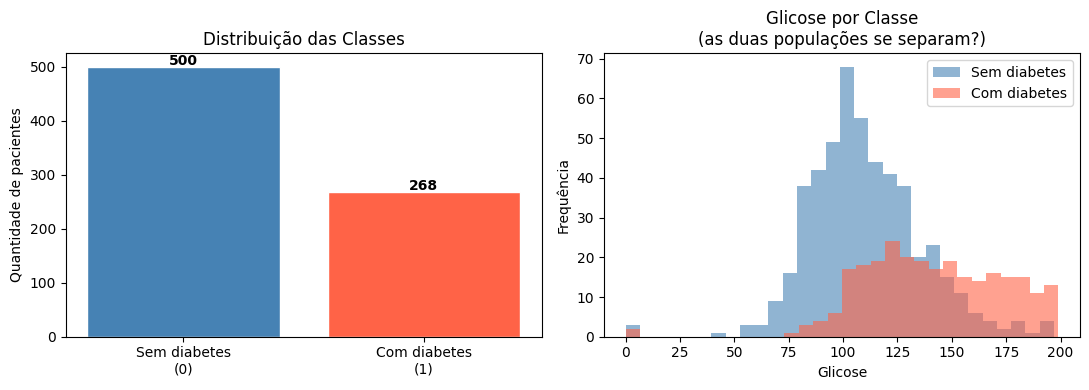

In [4]:
contagem = df['Outcome'].value_counts()
proporcao = df['Outcome'].value_counts(normalize=True)

print("Distribuição das classes:")
print(f"  Sem diabetes (0): {contagem[0]:>4} pacientes  ({proporcao[0]:.1%})")
print(f"  Com diabetes (1): {contagem[1]:>4} pacientes  ({proporcao[1]:.1%})")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Gráfico de barras
axes[0].bar(['Sem diabetes\n(0)', 'Com diabetes\n(1)'],
             [contagem[0], contagem[1]],
             color=['steelblue', 'tomato'], edgecolor='white')
axes[0].set_title('Distribuição das Classes')
axes[0].set_ylabel('Quantidade de pacientes')
for i, v in enumerate([contagem[0], contagem[1]]):
    axes[0].text(i, v + 3, str(v), ha='center', fontweight='bold')

# Glicose por classe (pré-visualização da separação)
axes[1].hist(df[df['Outcome']==0]['Glucose'], bins=30,
              alpha=0.6, color='steelblue', label='Sem diabetes')
axes[1].hist(df[df['Outcome']==1]['Glucose'], bins=30,
              alpha=0.6, color='tomato', label='Com diabetes')
axes[1].set_xlabel('Glicose')
axes[1].set_ylabel('Frequência')
axes[1].set_title('Glicose por Classe\n(as duas populações se separam?)')
axes[1].legend()

plt.tight_layout()
plt.show()

**Observações importantes:**

1. As classes estão **desbalanceadas**: 65% sem diabetes, 35% com. Isso não é dramático, mas precisamos lembrar — acurácia sozinha pode enganar aqui.

2. O histograma de glicose já mostra uma **separação visual** entre as duas classes. Pessoas com diabetes tendem a ter glicose mais alta. Isso sugere que glicose será uma variável importante para o modelo.

Vamos explorar mais:

In [5]:
# Comparando médias das variáveis entre as duas classes
medias = df.groupby('Outcome').mean().round(1).T
medias.columns = ['Sem diabetes', 'Com diabetes']
medias['Diferença %'] = ((medias['Com diabetes'] - medias['Sem diabetes'])
                          / medias['Sem diabetes'] * 100).round(1).astype(str) + '%'

print("Médias por classe:")
print(medias.to_string())

Médias por classe:
                          Sem diabetes  Com diabetes Diferença %
Pregnancies                        3.3           4.9       48.5%
Glucose                          110.0         141.3       28.5%
BloodPressure                     68.2          70.8        3.8%
SkinThickness                     19.7          22.2       12.7%
Insulin                           68.8         100.3       45.8%
BMI                               30.3          35.1       15.8%
DiabetesPedigreeFunction           0.4           0.6       50.0%
Age                               31.2          37.1       18.9%


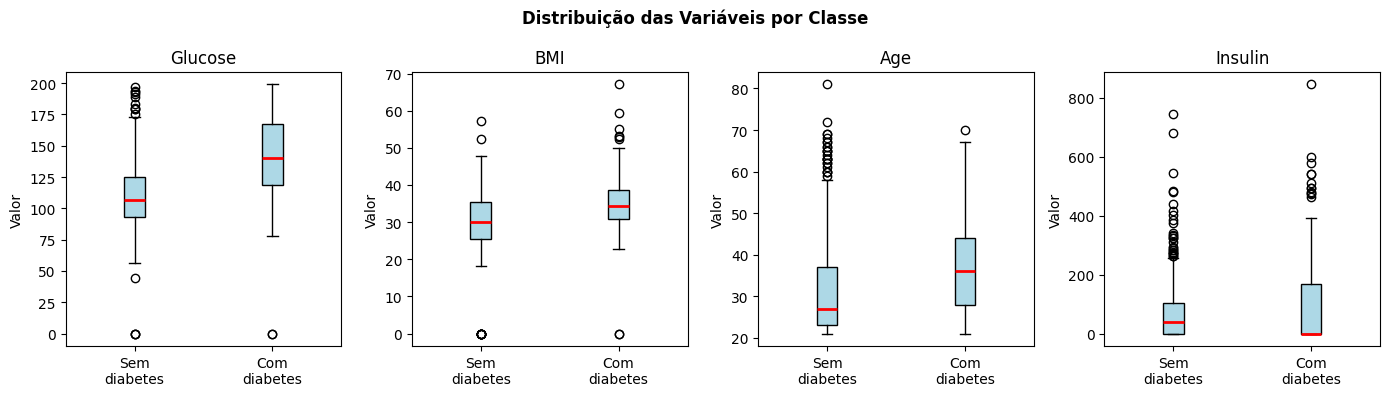

In [6]:
# Boxplots das variáveis mais relevantes
variaveis = ['Glucose', 'BMI', 'Age', 'Insulin']

fig, axes = plt.subplots(1, 4, figsize=(14, 4))

for ax, var in zip(axes, variaveis):
    sem = df[df['Outcome']==0][var]
    com = df[df['Outcome']==1][var]
    ax.boxplot([sem, com], labels=['Sem\ndiabetes', 'Com\ndiabetes'],
                patch_artist=True,
                boxprops=dict(facecolor='lightblue'),
                medianprops=dict(color='red', linewidth=2))
    ax.set_title(var)
    ax.set_ylabel('Valor')

plt.suptitle('Distribuição das Variáveis por Classe', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

Os boxplots confirmam: glicose, BMI e idade são maiores em média nos pacientes com diabetes. O modelo vai aprender a usar essas diferenças para classificar.

---

## 3. Pré-processamento

Antes de treinar qualquer modelo, precisamos preparar os dados. O processo é o mesmo da aula anterior:

1. Separar features (X) e alvo (y)
2. Dividir em treino e teste
3. Aplicar scaling nas features

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separando features e alvo
X = df.drop(columns=['Outcome'])
y = df['Outcome']

# Dividindo treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,
    stratify=y   # ← garante que a proporção de classes seja igual no treino e no teste
)

# Scaling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Treino: {X_train.shape[0]} pacientes")
print(f"Teste:  {X_test.shape[0]} pacientes")
print(f"\nProporção de diabéticos no treino: {y_train.mean():.1%}")
print(f"Proporção de diabéticos no teste:  {y_test.mean():.1%}")

Treino: 614 pacientes
Teste:  154 pacientes

Proporção de diabéticos no treino: 34.9%
Proporção de diabéticos no teste:  35.1%


**O parâmetro `stratify=y`:** quando as classes estão desbalanceadas, existe o risco de a divisão aleatória colocar todos os casos raros em um único lado. O `stratify` garante que a proporção de cada classe seja **preservada** no treino e no teste. Sempre use isso em problemas de classificação com desbalanceamento.

---

## 4. Primeiro modelo: Regressão Logística

### O nome confunde — não é regressão!

Sim, o nome tem "Regressão". Não, ela não prevê números. É um classificador. O nome é histórico e todos precisamos conviver com isso.

### O que ela faz?

A Regressão Logística pega as variáveis de entrada, calcula uma combinação delas (igual à regressão linear), e depois **transforma esse número em uma probabilidade** entre 0 e 1.

```
Passo 1 (igual à regressão linear):
z = a₁×glicose + a₂×bmi + a₃×idade + ... + b

Passo 2 (o que é diferente — a função logística):
probabilidade = 1 / (1 + e^(-z))
```

Esse segundo passo — a **função logística** (ou sigmóide) — é o truque. Ela espreme qualquer número real para o intervalo [0, 1]. Então o resultado é sempre uma probabilidade.

### Da probabilidade para a classe

Com a probabilidade em mãos, aplicamos um **limiar de decisão**:

```
se probabilidade >= 0.5 → prevê classe 1 (tem diabetes)
se probabilidade  < 0.5 → prevê classe 0 (não tem diabetes)
```

O limiar padrão é 0.5, mas pode ser ajustado — como vimos na aula anterior quando falamos de Precisão vs Recall.

### A fronteira de decisão

A Regressão Logística cria uma **linha reta** (ou hiperplano, em múltiplas dimensões) que separa as duas classes. Tudo de um lado = classe 0. Tudo do outro = classe 1.

Isso a torna simples, interpretável e rápida — mas também limita: se as classes não forem separáveis por uma linha reta, ela vai ter dificuldade.

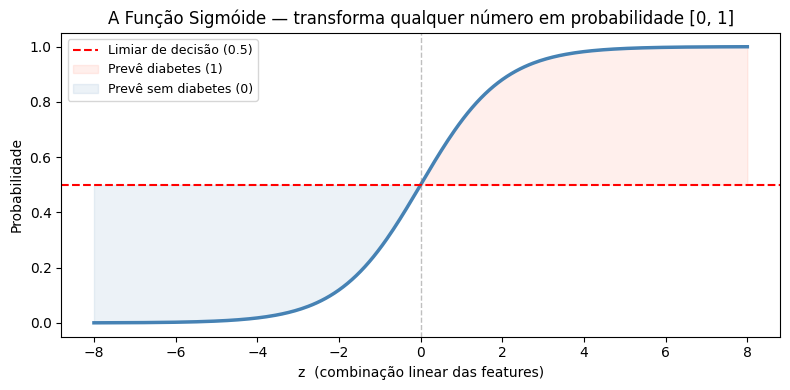

Exemplos:
  z =  -5 → probabilidade = 0.007 → classe prevista = 0
  z =  -2 → probabilidade = 0.119 → classe prevista = 0
  z =   0 → probabilidade = 0.500 → classe prevista = 1
  z =   2 → probabilidade = 0.881 → classe prevista = 1
  z =   5 → probabilidade = 0.993 → classe prevista = 1


In [8]:
# Visualizando a função sigmóide — o coração da Regressão Logística
z = np.linspace(-8, 8, 300)
sigmoid = 1 / (1 + np.exp(-z))

plt.figure(figsize=(8, 4))
plt.plot(z, sigmoid, color='steelblue', linewidth=2.5)
plt.axhline(0.5, color='red', linestyle='--', linewidth=1.5, label='Limiar de decisão (0.5)')
plt.axvline(0,   color='gray', linestyle='--', linewidth=1,   alpha=0.5)
plt.fill_between(z, sigmoid, 0.5, where=(sigmoid >= 0.5),
                  alpha=0.1, color='tomato', label='Prevê diabetes (1)')
plt.fill_between(z, sigmoid, 0.5, where=(sigmoid < 0.5),
                  alpha=0.1, color='steelblue', label='Prevê sem diabetes (0)')
plt.xlabel('z  (combinação linear das features)')
plt.ylabel('Probabilidade')
plt.title('A Função Sigmóide — transforma qualquer número em probabilidade [0, 1]')
plt.legend(fontsize=9)
plt.ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

print("Exemplos:")
for z_ex in [-5, -2, 0, 2, 5]:
    p = 1 / (1 + np.exp(-z_ex))
    classe = 1 if p >= 0.5 else 0
    print(f"  z = {z_ex:>3} → probabilidade = {p:.3f} → classe prevista = {classe}")

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix,
                               classification_report, ConfusionMatrixDisplay)

# Treinando o modelo
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)

# Previsões
y_pred_lr    = lr.predict(X_test_sc)          # classe: 0 ou 1
y_proba_lr   = lr.predict_proba(X_test_sc)[:, 1]  # probabilidade de ser 1

acuracia_lr = accuracy_score(y_test, y_pred_lr)
print(f"Acurácia da Regressão Logística: {acuracia_lr:.2%}")
print()
print("Relatório completo:")
print(classification_report(y_test, y_pred_lr, target_names=['Sem diabetes', 'Com diabetes']))

Acurácia da Regressão Logística: 71.43%

Relatório completo:
              precision    recall  f1-score   support

Sem diabetes       0.76      0.82      0.79       100
Com diabetes       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154



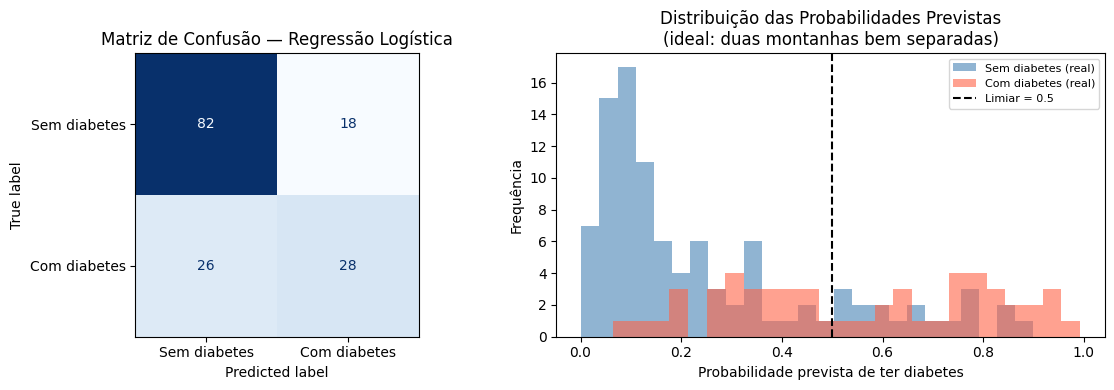

In [10]:
# Matriz de Confusão
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Matriz
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp  = ConfusionMatrixDisplay(cm_lr, display_labels=['Sem diabetes', 'Com diabetes'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusão — Regressão Logística')

# Distribuição das probabilidades previstas
axes[1].hist(y_proba_lr[y_test==0], bins=25, alpha=0.6,
              color='steelblue', label='Sem diabetes (real)')
axes[1].hist(y_proba_lr[y_test==1], bins=25, alpha=0.6,
              color='tomato', label='Com diabetes (real)')
axes[1].axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Limiar = 0.5')
axes[1].set_xlabel('Probabilidade prevista de ter diabetes')
axes[1].set_ylabel('Frequência')
axes[1].set_title('Distribuição das Probabilidades Previstas\n(ideal: duas montanhas bem separadas)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

### Lendo os resultados:

**Matriz de Confusão:** lembra da aula anterior? Temos VP, VN, FP e FN. No contexto médico:
- **Falso Negativo** (disse "sem diabetes", mas o paciente tem) → o mais perigoso. O paciente não receberá tratamento.
- **Falso Positivo** (disse "tem diabetes", mas o paciente não tem) → preocupante, mas menos grave — levará a exames adicionais.

**Distribuição das probabilidades:** quanto mais separadas as duas montanhas, melhor o modelo distingue as classes. Se estiverem sobrepostas, o modelo tem dificuldade.

---

### Os coeficientes da Regressão Logística

Assim como na Regressão Linear, cada variável tem um peso. Aqui, o coeficiente positivo significa que a variável **aumenta a probabilidade** de diabetes. Negativo significa que **diminui**.

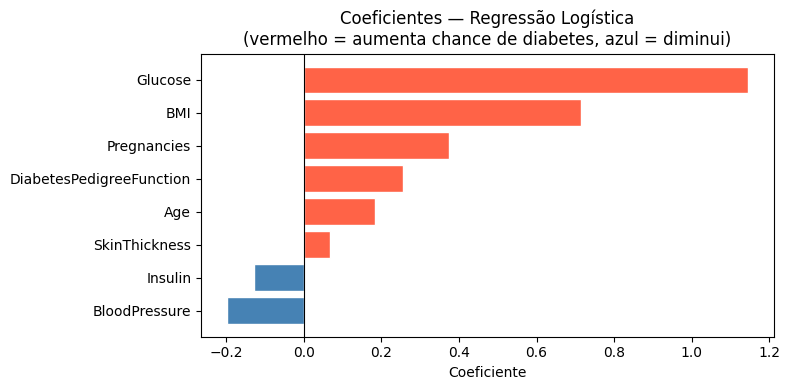


Top 3 que mais aumentam o risco de diabetes:
    Feature  Coeficiente
Pregnancies     0.373178
        BMI     0.713893
    Glucose     1.144151

Top 3 que mais diminuem o risco:
      Feature  Coeficiente
BloodPressure    -0.197637
      Insulin    -0.127308
SkinThickness     0.066535


In [11]:
coeficientes = pd.DataFrame({
    'Feature':     X.columns,
    'Coeficiente': lr.coef_[0]
}).sort_values('Coeficiente', ascending=True)

cores = ['tomato' if c > 0 else 'steelblue' for c in coeficientes['Coeficiente']]

plt.figure(figsize=(8, 4))
plt.barh(coeficientes['Feature'], coeficientes['Coeficiente'],
          color=cores, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coeficiente')
plt.title('Coeficientes — Regressão Logística\n(vermelho = aumenta chance de diabetes, azul = diminui)')
plt.tight_layout()
plt.show()

print("\nTop 3 que mais aumentam o risco de diabetes:")
print(coeficientes.tail(3)[['Feature', 'Coeficiente']].to_string(index=False))
print("\nTop 3 que mais diminuem o risco:")
print(coeficientes.head(3)[['Feature', 'Coeficiente']].to_string(index=False))

---

## 5. Segundo modelo: Árvore de Decisão

### A intuição — como você mesmo classifica

Imagine que você é médico e precisa decidir se um paciente tem diabetes. Você provavelmente faria algo assim:

```
Glicose > 140?
├── SIM → BMI > 30?
│         ├── SIM → DIABETES (alta probabilidade)
│         └── NÃO → Verificar outros fatores...
└── NÃO → Idade > 50?
           ├── SIM → Verificar insulina...
           └── NÃO → SEM DIABETES (baixa probabilidade)
```

Isso é exatamente o que uma **Árvore de Decisão** faz: ela aprende uma sequência de perguntas (condições) que, respondidas em ordem, levam a uma classificação.

### Como a árvore aprende as perguntas?

O algoritmo testa, para cada variável, **todos os possíveis pontos de corte** e escolhe aquele que melhor **separa as classes**.

**Critério de separação — Gini Impurity:**

Imagine que você tem uma caixa com bolas vermelhas e azuis completamente misturadas. Se você pegar uma bola aleatoriamente, qual a chance de pegar a errada? Alta — a caixa está "impura".

Agora imagine que todas as bolas vermelhas estão de um lado e todas as azuis do outro. Se pegar uma bola de qualquer lado, você sabe o que vai pegar — a caixa está "pura".

O Gini mede exatamente essa impureza. A árvore escolhe os cortes que **minimizam o Gini** — que deixam cada lado o mais puro possível.

### Vantagens da Árvore de Decisão:
- ✅ **Interpretável:** você consegue visualizar e explicar exatamente por que o modelo tomou cada decisão
- ✅ **Não precisa de scaling:** trabalha bem com variáveis em escalas diferentes
- ✅ **Captura relações não-lineares:** não precisa que a separação seja uma linha reta
- ✅ **Funciona com variáveis categóricas:** sem precisar de encoding

### Desvantagem principal:
- ⚠️ **Muito suscetível a overfitting:** uma árvore sem limite de profundidade memoriza o treino perfeitamente — mas falha no teste.

In [12]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Primeiro, vamos ver o que acontece sem limitar a profundidade
arvore_livre = DecisionTreeClassifier(random_state=42)  # sem limite!
arvore_livre.fit(X_train_sc, y_train)

acc_treino_livre = accuracy_score(y_train, arvore_livre.predict(X_train_sc))
acc_teste_livre  = accuracy_score(y_test,  arvore_livre.predict(X_test_sc))

print("=== Árvore SEM limite de profundidade ===")
print(f"Acurácia no TREINO: {acc_treino_livre:.2%}")
print(f"Acurácia no TESTE:  {acc_teste_livre:.2%}")
print(f"Profundidade da árvore: {arvore_livre.get_depth()}")
print(f"Número de folhas: {arvore_livre.get_n_leaves()}")
print()

# Agora limitando a profundidade
arvore = DecisionTreeClassifier(max_depth=4, random_state=42)
arvore.fit(X_train_sc, y_train)

y_pred_dt = arvore.predict(X_test_sc)
acc_treino = accuracy_score(y_train, arvore.predict(X_train_sc))
acc_teste  = accuracy_score(y_test,  y_pred_dt)

print("=== Árvore COM profundidade máxima = 4 ===")
print(f"Acurácia no TREINO: {acc_treino:.2%}")
print(f"Acurácia no TESTE:  {acc_teste:.2%}")
print(f"Profundidade da árvore: {arvore.get_depth()}")
print(f"Número de folhas: {arvore.get_n_leaves()}")

=== Árvore SEM limite de profundidade ===
Acurácia no TREINO: 100.00%
Acurácia no TESTE:  72.08%
Profundidade da árvore: 16
Número de folhas: 115

=== Árvore COM profundidade máxima = 4 ===
Acurácia no TREINO: 79.64%
Acurácia no TESTE:  79.87%
Profundidade da árvore: 4
Número de folhas: 12


**Olha o overfitting!** A árvore sem limite acerta **100% no treino** (decorou tudo!) mas vai mal no teste. Com `max_depth=4`, o desempenho no treino cai um pouco, mas o teste melhora — o modelo generalizou melhor.

Agora vamos visualizar a árvore — isso é uma das coisas mais poderosas desse modelo:

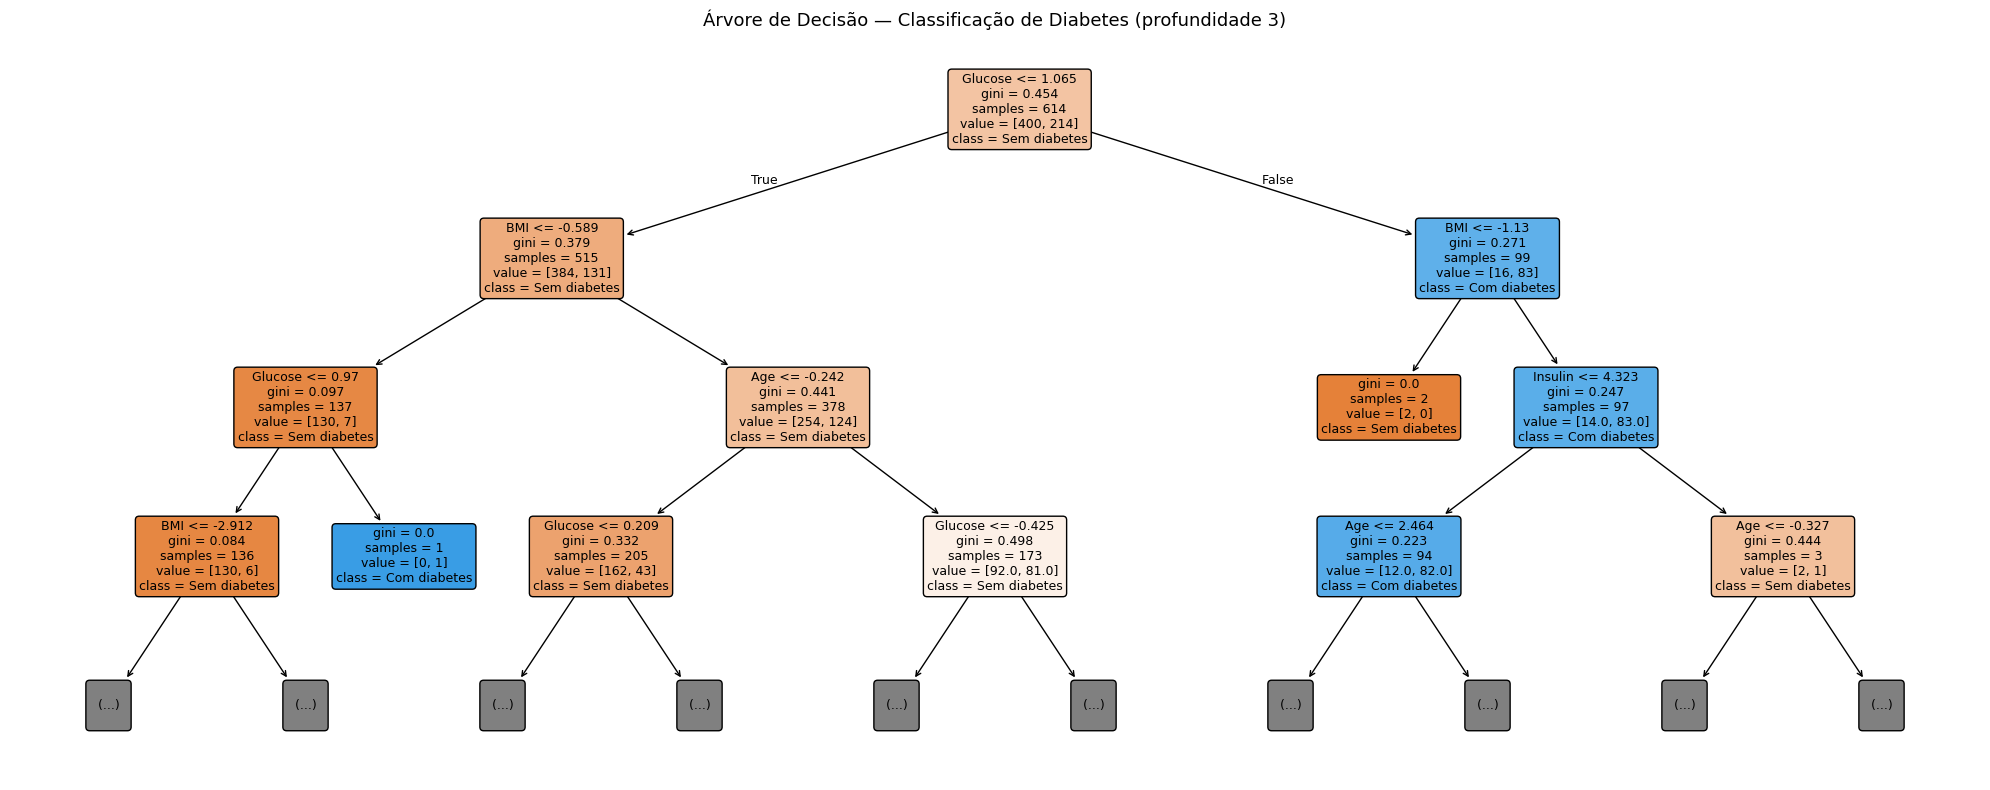

In [13]:
# Visualizando a árvore de decisão
plt.figure(figsize=(20, 8))
plot_tree(
    arvore,
    feature_names=X.columns.tolist(),
    class_names=['Sem diabetes', 'Com diabetes'],
    filled=True,
    rounded=True,
    fontsize=9,
    max_depth=3   # mostrando só 3 níveis para ficar legível
)
plt.title('Árvore de Decisão — Classificação de Diabetes (profundidade 3)', fontsize=13)
plt.tight_layout()
plt.show()

### Como ler a árvore:

Cada **nó** (caixinha) mostra:
- A **pergunta** que está sendo feita (ex: `Glucose <= 0.53`)
- O **Gini** — impureza desse nó (0 = puro, 0.5 = máxima mistura)
- O **samples** — quantos exemplos de treino chegaram aqui
- O **value** — quantos de cada classe: [sem diabetes, com diabetes]
- A **class** — qual seria a previsão se o caminho parasse aqui

A **cor** indica a classe dominante: azul = sem diabetes, laranja = com diabetes. Mais escuro = mais certeza.

Para classificar um paciente novo, você segue o caminho da raiz até uma folha respondendo as perguntas.

> **Atenção:** os valores das perguntas estão em escala padronizada (pós-StandardScaler). Por isso aparece `Glucose <= 0.53` em vez de `Glucose <= 140`. O modelo funciona correto — é só uma questão de como os dados foram transformados.

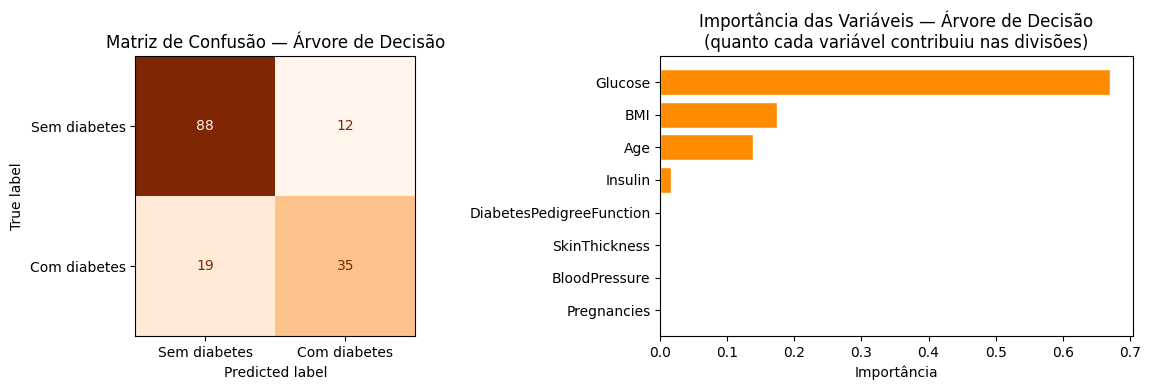

              precision    recall  f1-score   support

Sem diabetes       0.82      0.88      0.85       100
Com diabetes       0.74      0.65      0.69        54

    accuracy                           0.80       154
   macro avg       0.78      0.76      0.77       154
weighted avg       0.80      0.80      0.80       154



In [14]:
# Matriz de confusão da árvore
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm_dt = confusion_matrix(y_test, y_pred_dt)
disp2 = ConfusionMatrixDisplay(cm_dt, display_labels=['Sem diabetes', 'Com diabetes'])
disp2.plot(ax=axes[0], colorbar=False, cmap='Oranges')
axes[0].set_title('Matriz de Confusão — Árvore de Decisão')

# Importância das features
importancias = pd.DataFrame({
    'Feature': X.columns,
    'Importância': arvore.feature_importances_
}).sort_values('Importância', ascending=True)

axes[1].barh(importancias['Feature'], importancias['Importância'],
              color='darkorange', edgecolor='white')
axes[1].set_xlabel('Importância')
axes[1].set_title('Importância das Variáveis — Árvore de Decisão\n(quanto cada variável contribuiu nas divisões)')

plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_dt, target_names=['Sem diabetes', 'Com diabetes']))

**Feature Importance (Importância das Variáveis):** a árvore de decisão nos dá de graça uma medida de quais variáveis mais contribuíram para as divisões. Glicose domina — faz sentido médico!

---

## 6. Comparando os dois modelos

Agora temos dois classificadores. Qual é melhor?

Lembra da aula anterior: não existe resposta sem contexto. Vamos comparar por múltiplos ângulos.

In [15]:
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score

X_all_sc = scaler.fit_transform(X)

# Cross-validation para os dois modelos
cv_lr = cross_val_score(LogisticRegression(max_iter=1000), X_all_sc, y, cv=5, scoring='accuracy')
cv_dt = cross_val_score(DecisionTreeClassifier(max_depth=4), X_all_sc, y, cv=5, scoring='accuracy')

# Tabela comparativa
def metricas(y_true, y_pred, nome):
    return {
        'Modelo':     nome,
        'Acurácia':   f"{accuracy_score(y_true, y_pred):.2%}",
        'Precisão':   f"{precision_score(y_true, y_pred):.2%}",
        'Recall':     f"{recall_score(y_true, y_pred):.2%}",
        'F1-Score':   f"{f1_score(y_true, y_pred):.2%}",
    }

comparacao = pd.DataFrame([
    metricas(y_test, y_pred_lr, 'Regressão Logística'),
    metricas(y_test, y_pred_dt, 'Árvore de Decisão'),
])
print("=== Comparação no conjunto de TESTE ===")
print(comparacao.to_string(index=False))

print(f"\n=== Cross-Validation (5-Fold) ===")
print(f"Regressão Logística: {cv_lr.mean():.2%} ± {cv_lr.std():.2%}")
print(f"Árvore de Decisão:   {cv_dt.mean():.2%} ± {cv_dt.std():.2%}")

=== Comparação no conjunto de TESTE ===
             Modelo Acurácia Precisão Recall F1-Score
Regressão Logística   71.43%   60.87% 51.85%   56.00%
  Árvore de Decisão   79.87%   74.47% 64.81%   69.31%

=== Cross-Validation (5-Fold) ===
Regressão Logística: 77.09% ± 2.47%
Árvore de Decisão:   73.05% ± 2.88%


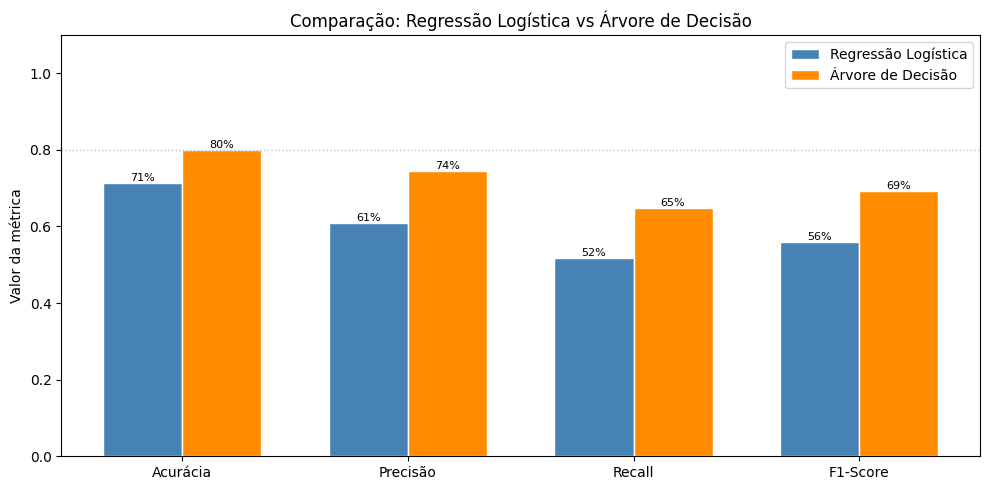

In [16]:
# Visualização comparativa
metricas_nomes = ['Acurácia', 'Precisão', 'Recall', 'F1-Score']
vals_lr = [
    accuracy_score(y_test, y_pred_lr),
    precision_score(y_test, y_pred_lr),
    recall_score(y_test, y_pred_lr),
    f1_score(y_test, y_pred_lr),
]
vals_dt = [
    accuracy_score(y_test, y_pred_dt),
    precision_score(y_test, y_pred_dt),
    recall_score(y_test, y_pred_dt),
    f1_score(y_test, y_pred_dt),
]

x = np.arange(len(metricas_nomes))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - width/2, vals_lr, width, label='Regressão Logística',
             color='steelblue', edgecolor='white')
b2 = ax.bar(x + width/2, vals_dt, width, label='Árvore de Decisão',
             color='darkorange', edgecolor='white')

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{bar.get_height():.0%}', ha='center', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(metricas_nomes)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Valor da métrica')
ax.set_title('Comparação: Regressão Logística vs Árvore de Decisão')
ax.legend()
ax.axhline(0.8, color='gray', linestyle=':', linewidth=1, alpha=0.5)
plt.tight_layout()
plt.show()

### Quem ganhou?

No caso específico desse dataset, os modelos têm desempenhos parecidos. Mas cada um tem características diferentes:

| | Regressão Logística | Árvore de Decisão |
|---|---|---|
| **Interpretabilidade** | Coeficientes lineares | Regras de decisão visuais |
| **Fronteira de decisão** | Linha reta | Linhas paralelas aos eixos |
| **Risco de overfitting** | Baixo | Alto (sem `max_depth`) |
| **Precisa de scaling** | Sim | Não |
| **Velocidade** | Muito rápida | Rápida |
| **Quando usar** | Relações lineares, quando interpretabilidade importa | Relações não-lineares, quando precisa explicar as regras |

---

## 7. Fronteiras de Decisão — visualizando como cada modelo "vê" o problema

Para entender intuitivamente a diferença entre os dois modelos, vamos plotar as **fronteiras de decisão** — a linha que separa os dois lados para cada modelo.

Para poder visualizar em 2D, vamos usar apenas as duas variáveis mais importantes: **Glicose** e **BMI**.

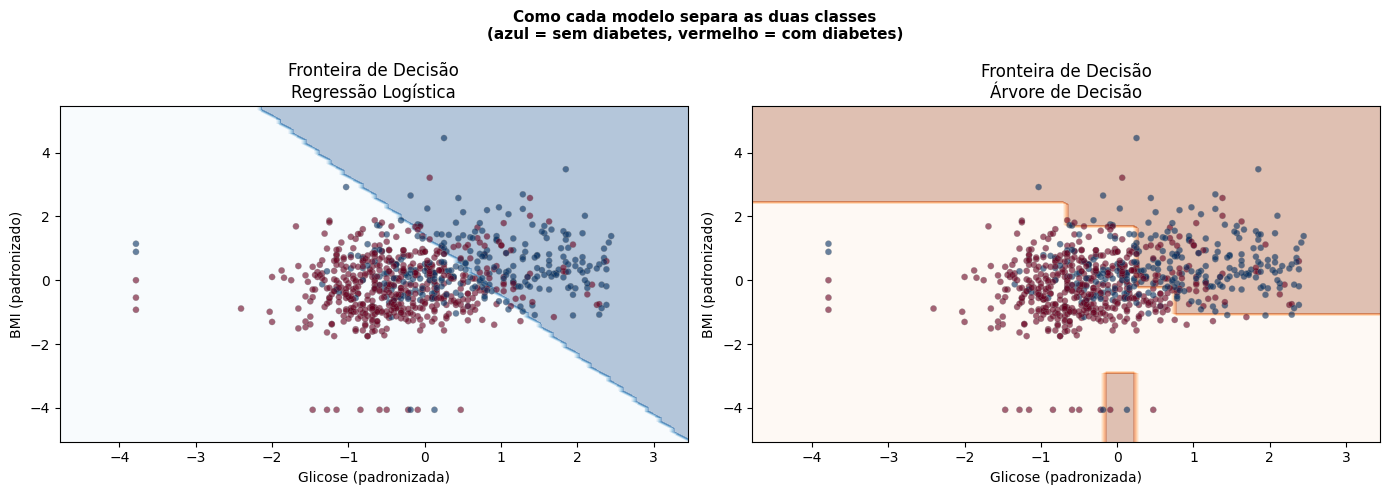

In [17]:
from sklearn.inspection import DecisionBoundaryDisplay

# Usando apenas 2 features para poder visualizar em 2D
X2 = df[['Glucose', 'BMI']].values
y2 = df['Outcome'].values

scaler2 = StandardScaler()
X2_sc   = scaler2.fit_transform(X2)

# Treina os dois modelos nas 2 features
lr2 = LogisticRegression(max_iter=1000, random_state=42)
dt2 = DecisionTreeClassifier(max_depth=4, random_state=42)
lr2.fit(X2_sc, y2)
dt2.fit(X2_sc, y2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, modelo, nome, cor in zip(
    axes,
    [lr2, dt2],
    ['Regressão Logística', 'Árvore de Decisão'],
    ['Blues', 'Oranges']
):
    DecisionBoundaryDisplay.from_estimator(
        modelo, X2_sc, ax=ax, cmap=cor, alpha=0.3, response_method='predict'
    )
    scatter = ax.scatter(
        X2_sc[:, 0], X2_sc[:, 1],
        c=y2, cmap='RdBu', edgecolors='gray', s=20, alpha=0.6, linewidths=0.3
    )
    ax.set_xlabel('Glicose (padronizada)')
    ax.set_ylabel('BMI (padronizado)')
    ax.set_title(f'Fronteira de Decisão\n{nome}')

plt.suptitle('Como cada modelo separa as duas classes\n(azul = sem diabetes, vermelho = com diabetes)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

**O que você vê:**

- **Regressão Logística:** fronteira **diagonal e suave** — uma única linha reta divide o espaço em dois. Simples e elegante, mas pode não capturar padrões complexos.

- **Árvore de Decisão:** fronteira **em degraus** — só faz cortes horizontais e verticais (paralelos aos eixos). Cada degrau corresponde a uma pergunta da árvore. Mais flexível, mas pode criar formas estranhas.

Nenhuma captura perfeitamente a separação (há muita sobreposição) — o que confirma que diabetes é difícil de prever só com glicose e BMI.

---

## 8. Como um modelo classifica um paciente novo?

Vamos fechar com um exemplo prático: criar um paciente hipotético e ver o que os dois modelos dizem.

In [18]:
# Paciente hipotético (valores nas unidades originais)
paciente = pd.DataFrame([{
    'Pregnancies': 3,
    'Glucose': 148,          # glicose alta
    'BloodPressure': 72,
    'SkinThickness': 35,
    'Insulin': 0,
    'BMI': 33.6,             # sobrepeso
    'DiabetesPedigreeFunction': 0.627,  # histórico familiar
    'Age': 50
}])

# Aplicando o mesmo scaling
paciente_sc = scaler.transform(paciente)

# Previsões
pred_lr = lr.predict(paciente_sc)[0]
prob_lr = lr.predict_proba(paciente_sc)[0][1]

pred_dt = arvore.predict(paciente_sc)[0]
prob_dt = arvore.predict_proba(paciente_sc)[0][1]

print("=" * 50)
print("PACIENTE HIPOTÉTICO:")
print(f"  Glicose: 148, BMI: 33.6, Idade: 50")
print(f"  Histórico familiar: 0.627 (relevante)")
print("=" * 50)
print(f"\nRegressão Logística:")
print(f"  Probabilidade de diabetes: {prob_lr:.1%}")
print(f"  Classe prevista: {'COM diabetes' if pred_lr == 1 else 'SEM diabetes'}")
print(f"\nÁrvore de Decisão:")
print(f"  Probabilidade de diabetes: {prob_dt:.1%}")
print(f"  Classe prevista: {'COM diabetes' if pred_dt == 1 else 'SEM diabetes'}")
print("=" * 50)

PACIENTE HIPOTÉTICO:
  Glicose: 148, BMI: 33.6, Idade: 50
  Histórico familiar: 0.627 (relevante)

Regressão Logística:
  Probabilidade de diabetes: 65.7%
  Classe prevista: COM diabetes

Árvore de Decisão:
  Probabilidade de diabetes: 57.9%
  Classe prevista: COM diabetes


> **Curiosidade:** esse paciente é exatamente o primeiro registro do dataset original, e a classe real é **1 (tem diabetes)**. Veja se os dois modelos acertaram!

---

## Recapitulando o que aprendemos hoje

```
CLASSIFICAÇÃO
│
├── O que é?
│   Prever uma CATEGORIA, não um número.
│   Binária (2 classes) ou Multiclasse (3+)
│
├── Regressão Logística
│   ├── Calcula combinação linear das features
│   ├── Aplica função sigmóide → transforma em probabilidade [0,1]
│   ├── Aplica limiar (padrão: 0.5) → classe final
│   ├── Fronteira de decisão: linha reta
│   └── Boa interpretabilidade via coeficientes
│
├── Árvore de Decisão
│   ├── Aprende sequência de perguntas (if/else)
│   ├── Cada divisão minimiza impureza (Gini)
│   ├── Fronteira de decisão: degraus (paralelos aos eixos)
│   ├── Muito visual e interpretável
│   └── Risco alto de overfitting — controlar max_depth!
│
└── Como avaliar?
    (tudo que você já viu na Aula 3)
    ├── Acurácia (mas cuidado com desbalanceamento)
    ├── Precisão, Recall, F1
    ├── Matriz de Confusão
    └── Cross-Validation
```

---

## Exercícios

---

### 🟢 Fácil

**Exercício 1 — Entendendo o limiar**

O modelo de Regressão Logística usa limiar 0.5 por padrão.

Mude o limiar para **0.3** e recalcule a Matriz de Confusão e as métricas.
- Quantos Falsos Negativos havia antes? E agora?
- O Recall aumentou ou diminuiu?
- No contexto médico (detectar diabetes), qual limiar você preferiria?

*Dica:* use `y_proba_lr >= 0.3` para gerar as previsões com novo limiar.

In [19]:
# Exercício 1


**Exercício 2 — Árvore mais funda ou mais rasa?**

Treine Árvores de Decisão com `max_depth` = 1, 2, 3, 4, 5, 10 e None (sem limite).

Para cada uma, calcule acurácia no treino e no teste.

Plote os dois em um gráfico de linha com o `max_depth` no eixo X.

- Qual profundidade parece o melhor equilíbrio?
- A partir de qual profundidade o overfitting fica evidente?

In [20]:
# Exercício 2


---

### 🟡 Médio

**Exercício 3 — Feature engineering simples**

Experimente treinar os modelos usando **apenas as 3 variáveis mais importantes** segundo a Árvore de Decisão.

- O desempenho cai muito?
- Quais variáveis foram descartadas?
- Um modelo mais simples (menos features) pode ter alguma vantagem?

In [21]:
# Exercício 3


**Exercício 4 — Criando um paciente e interpretando**

Crie 3 pacientes fictícios:
1. Perfil de baixo risco (glicose baixa, BMI normal, jovem)
2. Perfil de médio risco
3. Perfil de alto risco (glicose alta, BMI elevado, histórico familiar)

Para cada um:
- Calcule a probabilidade prevista pelos dois modelos
- Mostre qual caminho o paciente percorre na árvore de decisão

*Dica para o caminho na árvore:* use `arvore.decision_path(paciente_sc)`

In [22]:
# Exercício 4


---

### 🔴 Difícil

**Exercício 5 — O custo assimétrico dos erros**

No contexto médico, um **Falso Negativo** (dizer que o paciente não tem diabetes quando tem) é muito mais grave do que um Falso Positivo.

Imagine que o custo de um FN é **5x maior** do que o custo de um FP.

1. Para diferentes limiares (0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7), calcule o **custo total** = `FP × 1 + FN × 5`
2. Qual limiar minimiza esse custo?
3. Plote o gráfico de custo total por limiar
4. Reflita: por que usar a acurácia como métrica principal seria errado nesse problema?

In [23]:
# Exercício 5


**Exercício 6 — Multiclasse (bônus)**

Até agora trabalhamos com classificação binária (diabetes: sim/não).

Carregue o dataset `iris` do seaborn (`sns.load_dataset('iris')`) — que tem 3 classes de flores — e aplique o pipeline completo:

1. Exploração das classes
2. Treino/teste com `stratify`
3. Regressão Logística e Árvore de Decisão
4. Matriz de confusão (agora é 3×3!)
5. Comparação com cross-validation

O que muda quando passamos de 2 para 3 classes? A Matriz de Confusão muda como?

In [24]:
# Exercício 6


---

## Resumo Final

| Conceito | O que é | Como usar |
|---|---|---|
| **Classificação** | Prever uma categoria | Quando o alvo é sim/não, A/B/C |
| **Binária vs Multiclasse** | 2 classes vs 3+ classes | Define a complexidade do problema |
| **`stratify=y`** | Preserva proporção de classes no split | Sempre usar com classes desbalanceadas |
| **Regressão Logística** | Usa sigmóide para prever probabilidade | Rápida, interpretável, fronteira linear |
| **Função Sigmóide** | Transforma qualquer número em [0,1] | É o coração da Reg. Logística |
| **Limiar de decisão** | Ponto de corte para classificar | Padrão 0.5, mas ajustável conforme o custo dos erros |
| **Árvore de Decisão** | Sequência de perguntas if/else | Interpretável, não precisa de scaling |
| **Gini Impurity** | Mede impureza de um nó | Árvore minimiza o Gini em cada divisão |
| **`max_depth`** | Profundidade máxima da árvore | Controla overfitting — sempre defina! |
| **Feature Importance** | Contribuição de cada variável | Gratuito na Árvore de Decisão |
| **Fronteira de Decisão** | Como o modelo separa as classes | Linear (LR) vs degraus (Árvore) |

> **A frase que resume a aula:** *Classificação é regressão com a saída sendo uma categoria. Os modelos são diferentes, mas o pipeline — explorar, pré-processar, treinar, avaliar — é sempre o mesmo.*